# Debt Sustainability Analysis — Sub-Saharan Africa (2010–2023)

## Key Finding
Angola is the highest-risk country in this sample — debt growing 10.5pp faster 
than GDP with only 20% government revenue/GDP, leaving little fiscal buffer. 
Zambia shows sustained multi-year debt stress pre-dating its 2020 default. 
Nigeria and South Africa sit in moderate territory but trend upward post-2019.

## Data Sources
- World Bank Open Data (wbgapi)
- Indicators: External debt (% GNI), GDP growth, Government revenue (% GDP), 
  Debt service (% exports)
- Countries: NGA, GHA, KEN, ZAF, ETH, CMR, ZMB, AGO
- Period: 2010–2023

## Data Gaps
- Nigeria: government revenue data unavailable in World Bank database
- Ethiopia: external debt data unavailable

In [7]:
import sys
sys.path.append('../../../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils.data_fetcher import fetch_wb, save_data

print("All imports successful")

All imports successful


In [8]:
import importlib
import utils.data_fetcher
importlib.reload(utils.data_fetcher)
from utils.data_fetcher import fetch_wb, save_data

In [9]:
COUNTRIES = ['NGA', 'GHA', 'KEN', 'ZAF', 'ETH', 'CMR', 'ZMB', 'AGO']

INDICATORS = {
    'ext_debt_pct_gni':  'DT.DOD.DECT.GN.ZS',
    'gdp_growth':        'NY.GDP.MKTP.KD.ZG',
    'govt_revenue_gdp':  'GC.REV.XGRT.GD.ZS',
    'debt_service_exp':  'DT.TDS.DECT.EX.ZS',
}

df = fetch_wb(INDICATORS, COUNTRIES, 2010, 2023)
save_data(df, '../../data/debt_raw.csv')

print(df.shape)
print(df.head(10))

Saved: ../../data/debt_raw.csv
(112, 6)
  country  year  ext_debt_pct_gni  gdp_growth  govt_revenue_gdp  \
0     AGO  2010         35.391161    5.293666         30.691895   
1     AGO  2011         33.968783    3.593870         39.704464   
2     AGO  2012         30.744680    8.503123         32.309516   
3     AGO  2013         35.314171    4.883061         31.746284   
4     AGO  2014         35.960198    4.655724         27.365768   
5     AGO  2015         56.780155    0.763178         16.570785   
6     AGO  2016        114.845095   -1.700530         13.852329   
7     AGO  2017         84.940483   -0.149396         14.288437   
8     AGO  2018         84.284363   -0.594411         20.049103   
9     AGO  2019         96.594727   -0.204680         20.783325   

   debt_service_exp  
0          5.741133  
1          5.745641  
2          8.394215  
3          8.272542  
4         13.428758  
5         24.785302  
6         38.075644  
7         25.429224  
8         28.535397  
9 

In [10]:
df = df.sort_values(['country', 'year'])
df['debt_yoy_change'] = df.groupby('country')['ext_debt_pct_gni'].diff()
df['debt_gap'] = df['debt_yoy_change'] - df['gdp_growth']

print(df[['country', 'year', 'ext_debt_pct_gni', 'gdp_growth', 'debt_gap']].head(20))

   country  year  ext_debt_pct_gni  gdp_growth   debt_gap
0      AGO  2010         35.391161    5.293666        NaN
1      AGO  2011         33.968783    3.593870  -5.016248
2      AGO  2012         30.744680    8.503123 -11.727227
3      AGO  2013         35.314171    4.883061  -0.313570
4      AGO  2014         35.960198    4.655724  -4.009696
5      AGO  2015         56.780155    0.763178  20.056779
6      AGO  2016        114.845095   -1.700530  59.765470
7      AGO  2017         84.940483   -0.149396 -29.755215
8      AGO  2018         84.284363   -0.594411  -0.061709
9      AGO  2019         96.594727   -0.204680  12.515044
10     AGO  2020        148.159899   -4.042447  55.607620
11     AGO  2021        108.138096    2.102753 -42.124556
12     AGO  2022         62.711515    4.216003 -49.642583
13     AGO  2023         74.562864    1.263308  10.588041
14     CMR  2010         11.709977    2.899025        NaN
15     CMR  2011         10.203551    3.379211  -4.885638
16     CMR  20

In [11]:
latest_year = df.groupby('country')['year'].transform('max')
latest = df[df['year'] == latest_year].copy()

summary = latest[['country', 'ext_debt_pct_gni', 'gdp_growth',
                   'govt_revenue_gdp', 'debt_service_exp', 'debt_gap']].copy()

summary['risk_tier'] = pd.cut(
    summary['debt_gap'],
    bins=[-np.inf, 0, 5, np.inf],
    labels=['Low', 'Moderate', 'High']
)

print(summary.sort_values('debt_gap', ascending=False).to_string(index=False))

country  ext_debt_pct_gni  gdp_growth  govt_revenue_gdp  debt_service_exp  debt_gap risk_tier
    AGO         74.562864    1.263308         20.635169         33.454553 10.588041      High
    NGA         29.036832    3.326846               NaN         15.391920  3.523252  Moderate
    ZMB        110.675742    5.367943               NaN          8.223661  1.633854  Moderate
    ZAF         44.161044    0.806105         29.809309         16.500526  0.255421  Moderate
    KEN         40.423252    5.719992         18.638829         21.113104 -2.173643       Low
    CMR         31.881636    3.347563               NaN         20.149742 -6.438113       Low
    GHA         55.296376    3.140091         15.022264         15.284998 -7.866462       Low
    ETH               NaN    6.594246          4.504963         14.339732       NaN       NaN


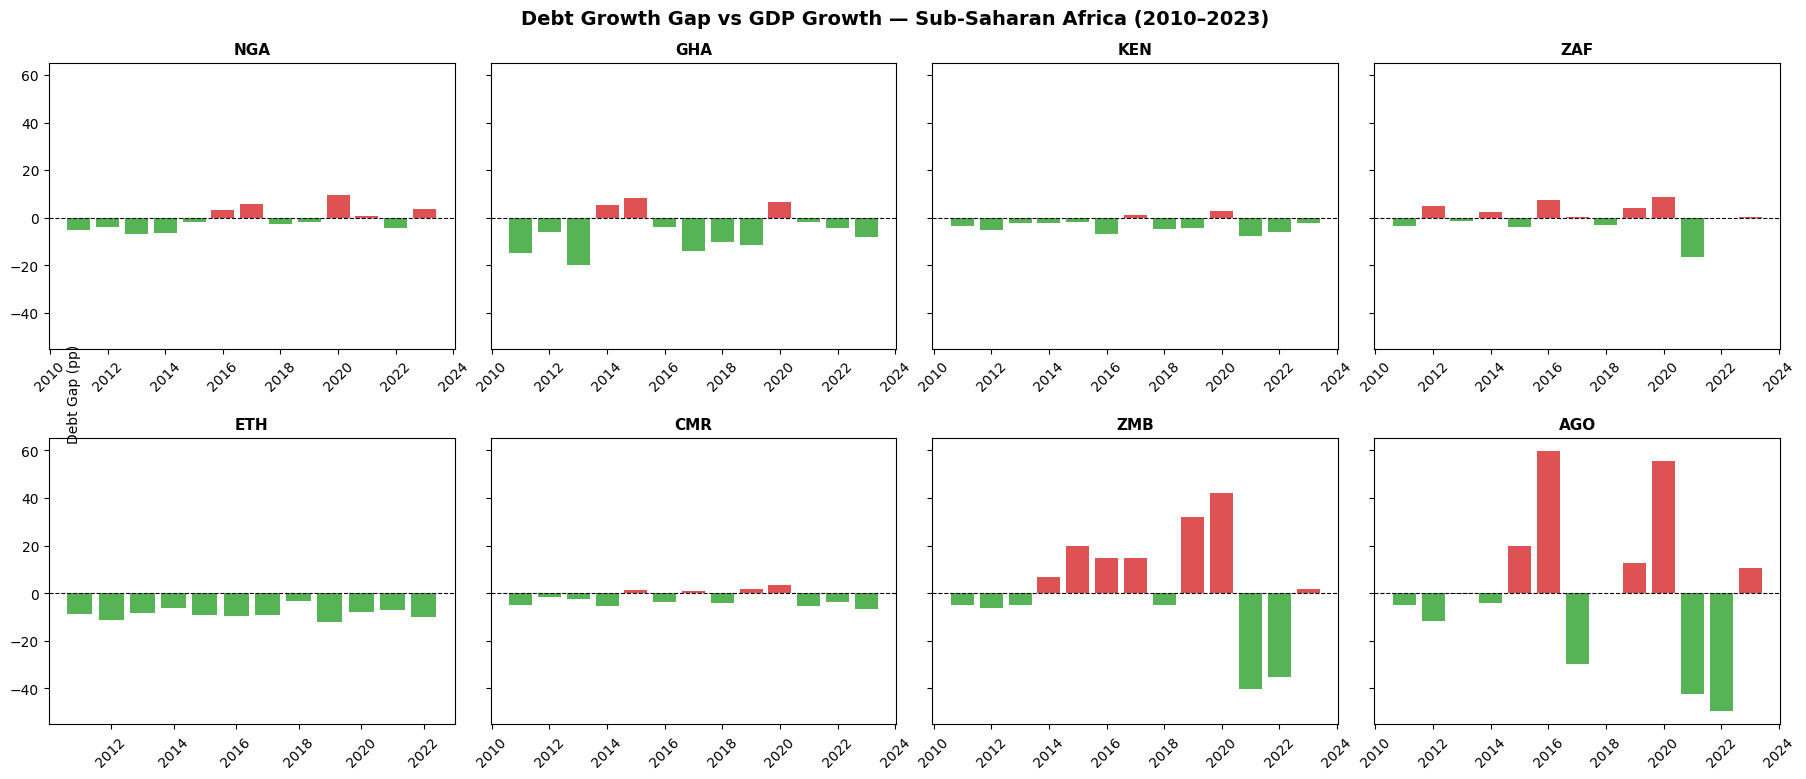

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=True)
axes = axes.flatten()

for i, country in enumerate(COUNTRIES):
    cdf = df[df['country'] == country]
    ax = axes[i]
    ax.bar(cdf['year'], cdf['debt_gap'],
           color=['#d62728' if x > 0 else '#2ca02c' for x in cdf['debt_gap']],
           alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(country, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Debt Growth Gap vs GDP Growth — Sub-Saharan Africa (2010–2023)',
             fontsize=14, fontweight='bold')
fig.text(0.04, 0.5, 'Debt Gap (pp)', va='center', rotation='vertical')
plt.tight_layout()
import os
os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/debt_gap_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

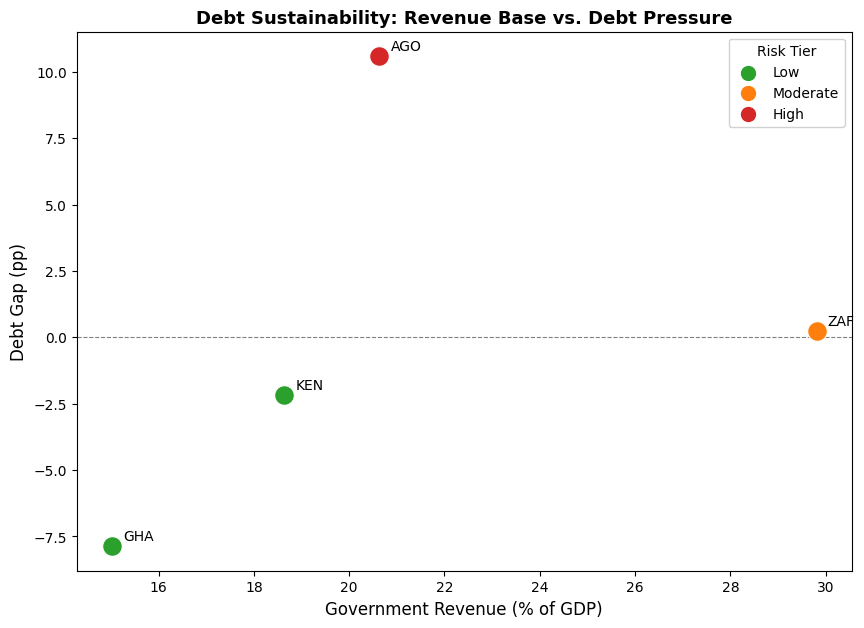

In [15]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = {'Low': '#2ca02c', 'Moderate': '#ff7f0e', 'High': '#d62728'}

for _, row in summary.iterrows():
    if pd.isna(row['debt_gap']) or pd.isna(row['govt_revenue_gdp']):
        continue
    color = colors[str(row['risk_tier'])]
    ax.scatter(row['govt_revenue_gdp'], row['debt_gap'],
               s=200, color=color, zorder=3, edgecolors='white', linewidth=0.8)
    ax.annotate(row['country'],
                (row['govt_revenue_gdp'], row['debt_gap']),
                textcoords='offset points', xytext=(8, 4), fontsize=10)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Government Revenue (% of GDP)', fontsize=12)
ax.set_ylabel('Debt Gap (pp)', fontsize=12)
ax.set_title('Debt Sustainability: Revenue Base vs. Debt Pressure', fontsize=13, fontweight='bold')

for label, color in colors.items():
    ax.scatter([], [], color=color, label=label, s=100)
ax.legend(title='Risk Tier', framealpha=0.9)

os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/risk_scatter.png', dpi=150, bbox_inches='tight')
plt.show()